# 第 12 章 · 二维 Diffusion 代码实验

[章节网页](../ch12.html)

## 运行内容

- 生成二维点
- 加入高斯噪声
- 绘制去噪方向

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 用一组二维点演示加噪和去噪方向。
rng = np.random.default_rng(9)
clean_points = rng.normal([1.0, 1.0], [0.18, 0.18], size=(80, 2))
noise_points = rng.normal(size=clean_points.shape)
noise_level = 0.65
noisy_points = np.sqrt(1 - noise_level) * clean_points + np.sqrt(noise_level) * noise_points
denoised_points = 0.55 * noisy_points + 0.45 * clean_points.mean(axis=0)

toy_summary = pd.DataFrame(
    [
        {"阶段": "noisy", "到clean中心的平均距离": np.linalg.norm(noisy_points - clean_points.mean(axis=0), axis=1).mean()},
        {"阶段": "denoised", "到clean中心的平均距离": np.linalg.norm(denoised_points - clean_points.mean(axis=0), axis=1).mean()},
    ]
).round(3)
display(toy_summary)

,阶段,到clean中心的平均距离
0,noisy,1.111
1,denoised,0.611


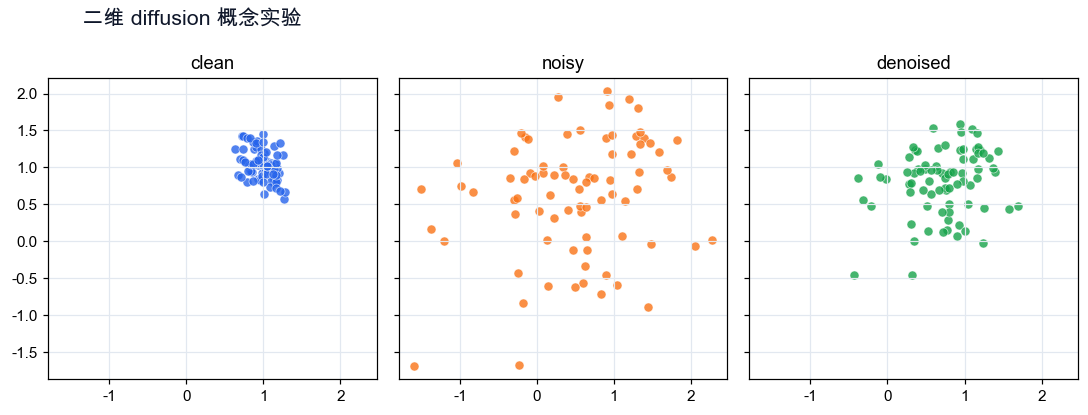

In [3]:
# 绘制二维点的加噪和去噪。
fig, axes = plt.subplots(1, 3, figsize=(10.0, 3.8), sharex=True, sharey=True)
for ax, pts, title, color in zip(
    axes,
    [clean_points, noisy_points, denoised_points],
    ["clean", "noisy", "denoised"],
    ["#2563eb", "#f97316", "#16a34a"],
):
    ax.scatter(pts[:, 0], pts[:, 1], s=35, alpha=0.8, color=color, edgecolors="white", linewidth=0.4)
    ax.set_title(title, fontweight="bold")
    ax.grid(True, color="#e2e8f0", linewidth=0.8)
fig.suptitle("二维 diffusion 概念实验", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()